In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import iqr

# Cargar la data
Con pandas carga los datos del archivo csv *Data_CHF_Zhao_2020_ATE.csv*

In [27]:
data_chf = pd.read_csv("Data_CHF_Zhao_2020_ATE.csv")

In [28]:
data_chf.describe()

,id,pressure [MPa],mass_flux [kg/m2-s],x_e_out [-],D_e [mm],D_h [mm],length [mm],chf_exp [MW/m2]
count,1865.000000,1865.000000,1865.000000,1865.000000,1865.000000,1865.000000,1865.000000,1865.000000
mean,933.000000,10.010949,2862.647721,0.016179,9.417212,16.167721,911.340483,3.854638
std,538.523444,4.282715,1656.412247,0.117575,6.333807,21.182870,726.718974,1.985535
min,1.000000,0.100000,0.000000,-0.866700,1.000000,1.000000,10.000000,0.800000
25%,467.000000,6.890000,1519.000000,-0.048300,5.600000,5.600000,432.000000,2.400000
50%,933.000000,10.340000,2590.000000,0.024400,8.500000,10.300000,625.000000,3.500000
75%,1399.000000,13.790000,3933.000000,0.100600,11.100000,15.200000,1778.000000,4.800000
max,1865.000000,20.680000,7975.000000,0.232000,37.500000,120.000000,3048.000000,19.300000


Creamos una lista con las variables numericas

In [29]:
numerical_cols = [
    'pressure [MPa]', 'mass_flux [kg/m2-s]', 'x_e_out [-]',
    'D_e [mm]', 'D_h [mm]', 'length [mm]', 'chf_exp [MW/m2]'
]

# Analizando los datos númericos

Para realizar un análisis de incertidumbre en los datos, es fundamental calcular y entender diversas medidas de dispersión y error. A continuación, se describen las medidas de dispersión y error utilizadas para evaluar la variabilidad y la precisión de los datos.


## Medidas de Disperción
### Media: 
Representa el valor promedio de los datos y se calcula sumando todos los valores y dividiéndolos por el número total de observaciones. La media es útil para obtener una visión general de la magnitud típica de los valores en un conjunto de datos.

### Desviación Estándar
Mide la variabilidad o dispersión de los datos alrededor de la media. Es crucial para evaluar la variabilidad de los datos.

### SEM (Error Estándar de la Media)
El Error Estándar de la Media (SEM) es una medida que describe cuán precisamente la media de una muestra representa la media de la población general. 
El SEM se calcula dividiendo la desviación estándar de la muestra por la raíz cuadrada del número de observaciones en la muestra.
$$
SEM = \frac{\sigma}{\sqrt{n}}
$$

### SEM % of Mean (Error Estándar de la Media como Porcentaje de la Media)
El SEM % of Mean también expresa el SEM como un porcentaje de la media.Este valor proporciona una medida de cuán significativa es la incertidumbre alrededor de la media en términos relativos al tamaño de la media misma. Es útil para comparar la precisión de las medias entre diferentes conjuntos de datos donde las escalas de medición pueden diferir.

$$
\text{SEM \% of Mean} = \frac{SEM}{\mu} \times 100
$$


###  Rango Intercuartílico (IQR) 
El IQR es una medida de dispersión estadística que se utiliza para describir la variabilidad de los datos al concentrarse en la parte central de una distribución. El IQR es la diferencia entre el tercer cuartil (Q3) y el primer cuartil (Q1) de los datos. Estos cuartiles dividen el conjunto de datos en cuatro partes iguales.
$$
\text{IQR} = Q3 - Q1
$$


Calcular para la lista de variables numericas:
- Media
- desviación estándar
- SEM (Error Estándar de la Media)
- Error Estándar de la Media como Porcentaje de la Media
- IQR


Debemos almacenar los resultados en un data frame de pandas, el data fame lo debemos crear a partir de un diccionario.

El resultado debe ser el siguiente

| Variable     | Mean       | Standard Deviation | SEM       | SEM % of Mean | IQR    |
|--------------|------------|---------------------|-----------|---------------|--------|
| pressure [MPa]| 10.010949  | 4.282715            | 0.099170  | 0.990614      | 6.9000 |
| mass_flux [kg/m²-s] | 2862.647721 | 1656.412247  | 38.355621 | 1.339865      | 2414.0000 |
| x_e_out [-]  | 0.016179   | 0.117575            | 0.002723  | 16.827823     | 0.1489 |
| D_e [mm]     | 9.417212   | 6.333807            | 0.146665  | 1.557410      | 5.5000 |
| D_h [mm]     | 16.167721  | 21.182870           | 0.490507  | 3.033867      | 9.6000 |
| length [mm]  | 911.340483 | 726.718974          | 16.827790 | 1.846488      | 1346.0000 |
| chf_exp [MW/m²] | 3.854638  | 1.985535           | 0.045977  | 1.192764      | 2.4000 |



In [30]:
# Desviación estándar de las columnas numéricas
std_devs = data_chf[numerical_cols].std()

# Medias de las columnas numéricas
means = data_chf[numerical_cols].mean()

# Cantidad de muestras por variable
n_samples = data_chf[numerical_cols].count()

# Error estándar medio (SEM)
sems = std_devs / (n_samples ** 0.5)

# Porcentaje del error estándar respecto a la media
sem_percentage = (sems / means) * 100

# IQR usando la función iqr de scipy.stats
iqr_data = data_chf[numerical_cols].apply(iqr)

# Crear un DataFrame para mostrar los resultados
uncertainty_df = pd.DataFrame({
    "Media": means,
    "Desviación estándar": std_devs,
    "Muestras": n_samples,
    "Error estándar (SEM)": sems,
    "% Error respecto a la media": sem_percentage,
    "IQR": iqr_data
})

uncertainty_df


,Media,Desviación estándar,Muestras,Error estándar (SEM),% Error respecto a la media,IQR
pressure [MPa],10.010949,4.282715,1865,0.099170,0.990614,6.9000
mass_flux [kg/m2-s],2862.647721,1656.412247,1865,38.355621,1.339865,2414.0000
x_e_out [-],0.016179,0.117575,1865,0.002723,16.827823,0.1489
D_e [mm],9.417212,6.333807,1865,0.146665,1.557410,5.5000
D_h [mm],16.167721,21.182870,1865,0.490507,3.033867,9.6000
length [mm],911.340483,726.718974,1865,16.827790,1.846488,1346.0000
chf_exp [MW/m2],3.854638,1.985535,1865,0.045977,1.192764,2.4000


## Interpretando las medidas de dispersión
Escribe en un celda en markdown la interpretación de los resultados en la tabla de medidas de dispersión

## Interpretación de Resultados de las medidas de dispersión

### Pressure [MPa]
- La presión promedio registrada es de aproximadamente 10 MPa, lo cual sugiere condiciones moderadas de operación.
- Existe una dispersión notable (desviación estándar de 4.28 MPa), aunque el error estándar y su porcentaje relativo son bajos, lo cual indica que la estimación de la media es confiable.
- La mayoría de los valores se encuentran en un rango relativamente estrecho, como lo sugiere el IQR de 6.9.

---

### Mass Flux [kg/m²-s]
- Se observa un flujo de masa bastante alto en promedio (2862.6 kg/m²-s), reflejando condiciones de enfriamiento exigentes.
- La alta desviación estándar y el IQR muy elevado evidencian una gran dispersión entre los datos, probablemente debido a diferentes configuraciones experimentales.
- A pesar de esta variabilidad, el SEM y su porcentaje son aceptables, lo que sugiere que el valor medio tiene una estimación sólida.

---

### x_e_out [-]
- El valor medio de esta variable es bajo (0.016), lo que indica que la mayoría de los puntos están cerca de condiciones de salida líquida.
- Aunque la desviación estándar es relativamente alta comparada con su media, el SEM es muy bajo, lo que indica precisión en la media.
- El IQR también es bajo, sugiriendo que la mayoría de los datos se concentran en un rango estrecho.

---

### D_e [mm]
- El diámetro equivalente tiene una media cercana a los 9.4 mm, con una dispersión moderada.
- El error estándar es pequeño y su porcentaje respecto a la media es bajo, lo cual sugiere que los valores promedio son estables.
- La distribución central, representada por el IQR, también refleja una concentración razonable de datos.

---

### D_h [mm]
- El diámetro hidráulico medio es mayor que el D_e, con una media de 16.17 mm.
- La desviación estándar es mayor, indicando más variación, pero el error estándar relativo sigue siendo aceptable.
- El IQR también refleja dispersión intermedia en los datos.

---

### Length [mm]
- La longitud media del canal o tubo es cercana a 911 mm, lo que indica una alta variabilidad de diseño entre experimentos.
- Tanto la desviación estándar como el IQR son grandes, lo que confirma esa variabilidad.
- A pesar de ello, el error relativo es bajo, lo que nos da confianza en el valor medio estimado.

---

### chf_exp [MW/m²]
- El flujo crítico de calor medio es de 3.85 MW/m², lo cual es consistente con niveles altos de transferencia de calor.
- La dispersión es moderada (desviación estándar de 1.98), y el error estándar bajo garantiza una buena estimación de la media.
- El IQR de 2.4 también refleja que la mayoría de los valores se concentran en un rango relativamente estrecho.

---

### Generalmente:
- En general, la mayoría de las variables muestran buena precisión en sus estimaciones medias gracias a los bajos SEMs.
- Variables como `mass_flux` y `length` presentan mayor dispersión, por lo que podrían requerir un análisis más detallado si se usan en modelos predictivos.

## Graficando la data

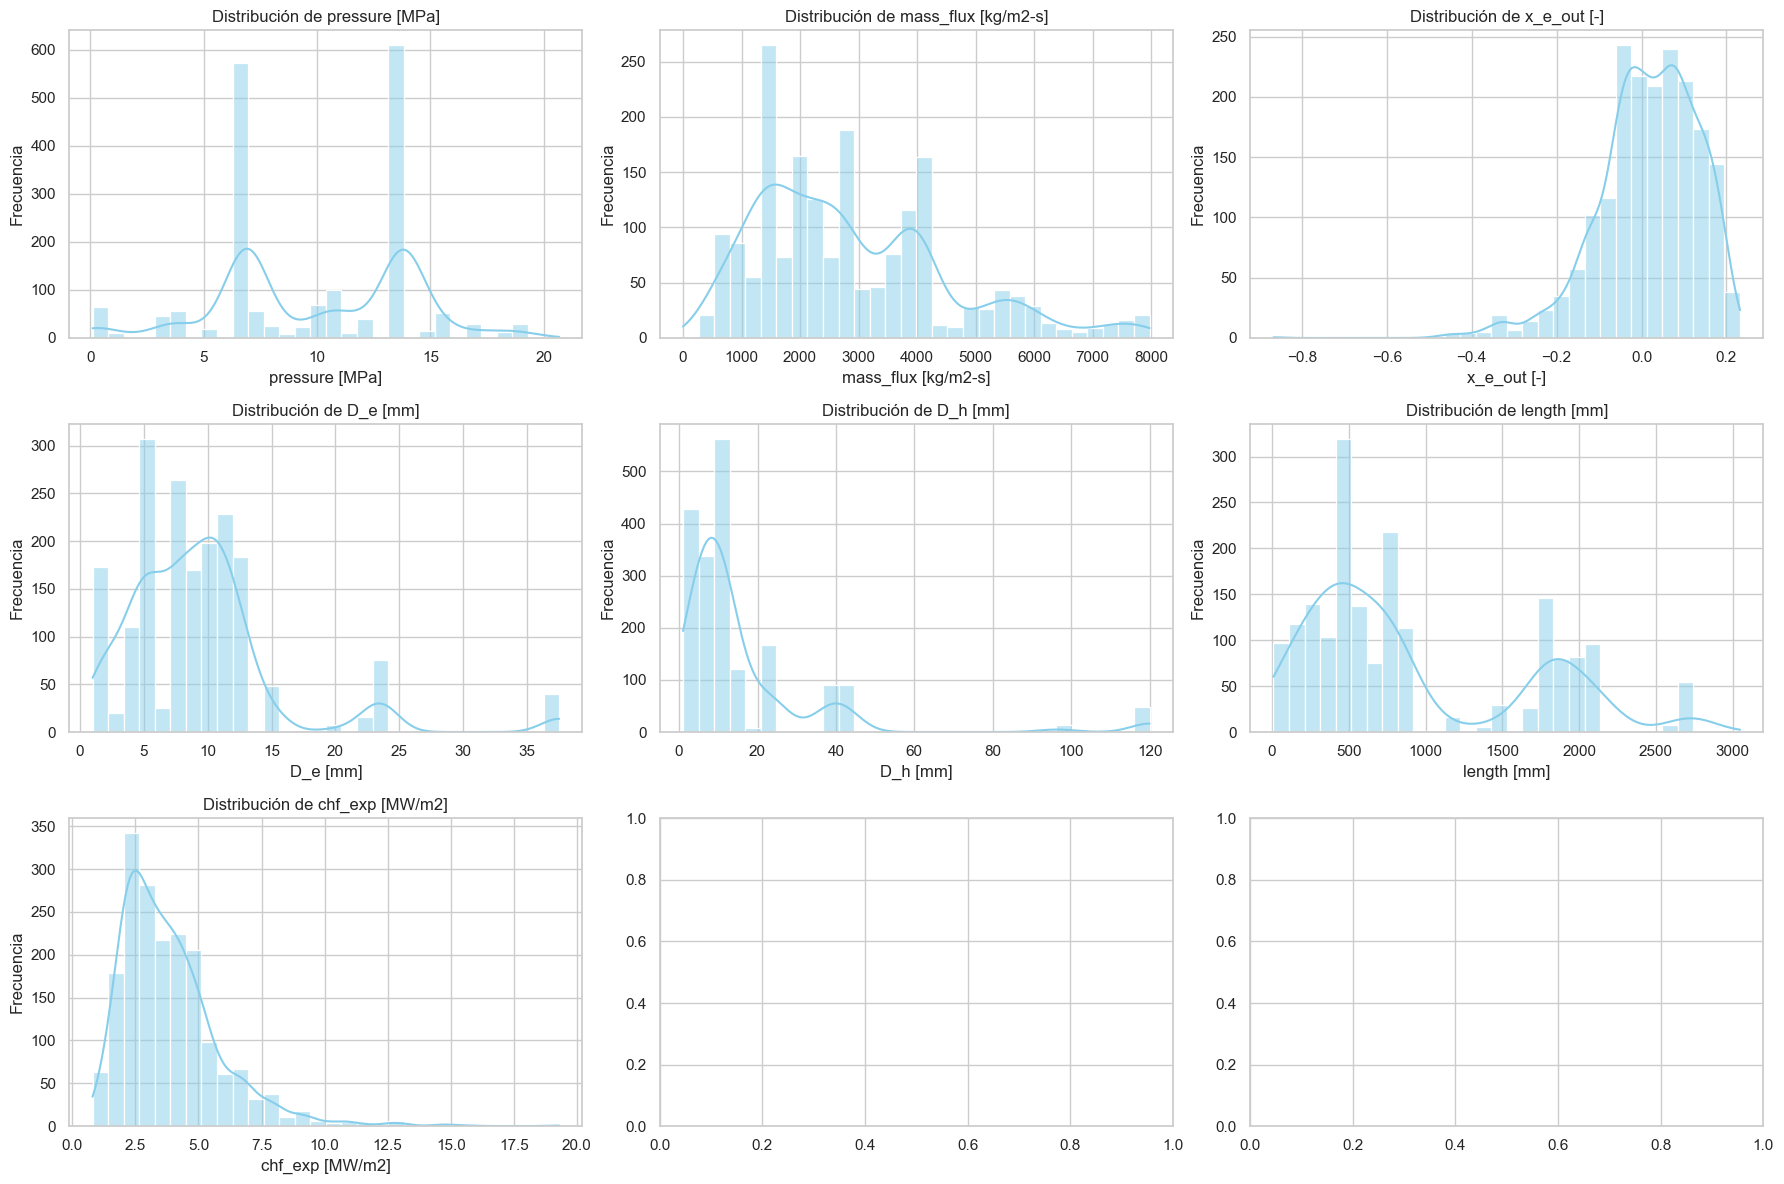

In [31]:
sns.set(style="whitegrid")
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

# Graficar histogramas para cada columna numérica
for i, col in enumerate(numerical_cols):
    sns.histplot(data_chf[col], ax=axes[i], kde=True, bins=30, color='skyblue')
    axes[i].set_title(f'Distribución de {col}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

# Ajustar el diseño
plt.tight_layout()

# Mostrar los gráficos
plt.show()